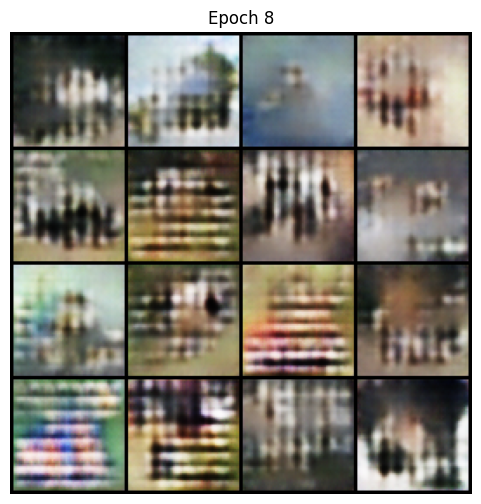

Checkpoint saved: ./gan_output/checkpoint_epoch8.pt


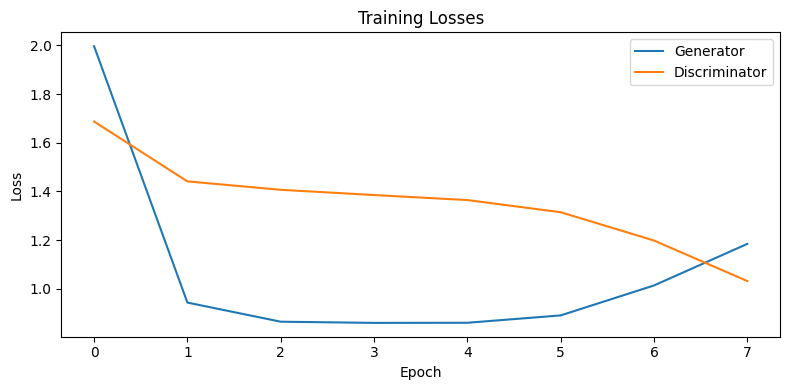

ValueError: Unknown format code 'd' for object of type 'str'

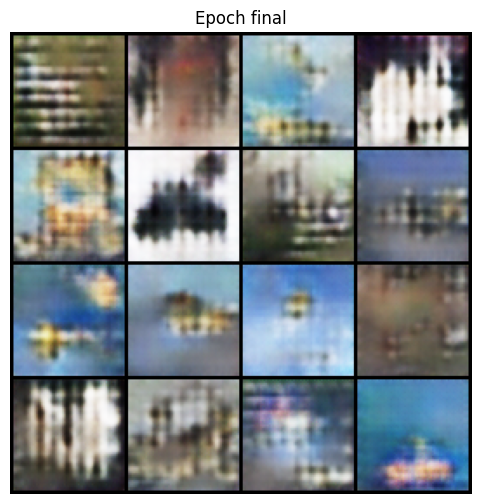

In [10]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import numpy as np

# =========================
# 1. Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# =========================
# 2. Hyperparameters
# =========================
batch_size  = 128
image_size  = 64
latent_dim  = 100
epochs      = 8
lr          = 0.0002
beta1       = 0.5     # Adam momentum for GANs
SAVE_DIR    = "./gan_output"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# 3. Dataset
# =========================
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, transform=transform, download=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,          # safe for Colab
    pin_memory=(device.type == "cuda")
)

# =========================
# 4. Weight Initialization
# =========================
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# =========================
# 5. Generator
# =========================
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # latent_dim → 512 feature maps, 4×4
            nn.ConvTranspose2d(latent_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 4 → 8
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 8 → 16
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 16 → 32
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 32 → 64
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

# =========================
# 6. Discriminator
# =========================
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # 64 → 32  (no BN on first layer — DCGAN convention)
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 → 16
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # 16 → 8
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # 8 → 4
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),

            # 4 → 1
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

# =========================
# 7. Initialize Models
# =========================
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

print(f"Generator params:     {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

criterion  = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, 0.999))

# Cosine LR decay over training
scheduler_G = optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=epochs)
scheduler_D = optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=epochs)

# Fixed noise to track visual progress consistently
fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)

# =========================
# 8. Visualisation Helper
# =========================
def show_generated(images, epoch, save=True):
    grid = make_grid(images, nrow=4, normalize=True, value_range=(-1, 1))
    npgrid = grid.permute(1, 2, 0).cpu().numpy()
    plt.figure(figsize=(6, 6))
    plt.imshow(npgrid)
    plt.axis("off")
    plt.title(f"Epoch {epoch}")
    if save:
        # Check if epoch is an integer to apply numerical formatting
        if isinstance(epoch, int):
            filename = f"{SAVE_DIR}/epoch_{epoch:03d}.png"
        else:
            # If epoch is a string, use it directly in the filename
            filename = f"{SAVE_DIR}/epoch_{epoch}.png"
        plt.savefig(filename, bbox_inches="tight")
    plt.show()

# =========================
# 9. Training Loop
# =========================
G_losses, D_losses = [], []

for epoch in range(1, epochs + 1):
    G.train(); D.train()
    epoch_G, epoch_D = [], []

    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        bsz = real_imgs.size(0)

        # ── Discriminator ───────────────────────────────
        optimizer_D.zero_grad()

        # Real images — label smoothing (0.9 instead of 1.0)
        out_real = D(real_imgs)
        lbl_real = torch.full_like(out_real, 0.9)
        loss_real = criterion(out_real, lbl_real)

        # Fake images
        noise = torch.randn(bsz, latent_dim, 1, 1, device=device)
        fake_imgs = G(noise).detach()          # detach: don't update G here
        out_fake = D(fake_imgs)
        lbl_fake = torch.zeros_like(out_fake)
        loss_fake = criterion(out_fake, lbl_fake)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        nn.utils.clip_grad_norm_(D.parameters(), max_norm=1.0)
        optimizer_D.step()

        # ── Generator (2 updates per D update) ─────────────────────
        for _ in range(2):
            optimizer_G.zero_grad()

            # Fresh noise each time — avoids stale graph after backward()
            noise_g = torch.randn(bsz, latent_dim, 1, 1, device=device)
            gen_imgs = G(noise_g)
            out_g    = D(gen_imgs)
            lbl_g    = torch.ones_like(out_g)   # G wants D to say "real"

            loss_G = criterion(out_g, lbl_g)
            loss_G.backward()
            nn.utils.clip_grad_norm_(G.parameters(), max_norm=1.0)
            optimizer_G.step()

        epoch_G.append(loss_G.item())
        epoch_D.append(loss_D.item())

        if i % 100 == 0:
            print(f"Epoch [{epoch:2d}/{epochs}] Step {i:4d} | "
                  f"D: {loss_D.item():.4f}  G: {loss_G.item():.4f}")

    # Step LR schedulers
    scheduler_G.step()
    scheduler_D.step()

    avg_G = np.mean(epoch_G)
    avg_D = np.mean(epoch_D)
    G_losses.append(avg_G)
    D_losses.append(avg_D)
    print(f"\n>>> Epoch {epoch} done — Avg D: {avg_D:.4f}  Avg G: {avg_G:.4f}\n")

    # Show & save sample images every epoch
    G.eval()
    with torch.no_grad():
        samples = G(fixed_noise).cpu()
    clear_output(wait=True)   # clears previous epoch's output for a clean view
    show_generated(samples, epoch)
    G.train()

    # Save checkpoints every 2 epochs
    if epoch % 2 == 0:
        torch.save({
            "epoch": epoch,
            "G_state": G.state_dict(),
            "D_state": D.state_dict(),
            "optG":    optimizer_G.state_dict(),
            "optD":    optimizer_D.state_dict()
        }, f"{SAVE_DIR}/checkpoint_epoch{epoch}.pt")
        print(f"Checkpoint saved: {SAVE_DIR}/checkpoint_epoch{epoch}.pt")

# =========================
# 10. Loss Curves
# =========================
plt.figure(figsize=(8, 4))
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/loss_curves.png")
plt.show()

# =========================
# 11. Final Generation
# =========================
G.eval()
with torch.no_grad():
    final_noise = torch.randn(16, latent_dim, 1, 1, device=device)
    final_imgs  = G(final_noise).cpu()

show_generated(final_imgs, epoch="final")
save_image(final_imgs, f"{SAVE_DIR}/final_generated.png", nrow=4, normalize=True)
print(f"All outputs saved to: {SAVE_DIR}/")